# Higher-Order Dynamics: Arnol's Cat Map

[Moreno Marzolla](https://www.moreno.marzolla.name/)m based on code available on [Github](https://github.com/zhanxw/cat/tree/master).

Written in March 2026,

Last modified March 2026.

---

[Arnold's cat map](https://en.wikipedia.org/wiki/Arnold%27s_cat_map)
is a continuous chaotic map that has been studied in the '60s by
the Russian mathematician [Vladimir Igorevich
Arnold](https://en.wikipedia.org/wiki/Vladimir_Arnold). The discrete cat map can be understood as a transformation
of a bitmapped image $P$ of size $N \times N$ into a new image $P'$ of
the same size. For each $0 \leq x, y < N$, the pixel of coordinates
$(x,y)$ in $P$ is mapped into a new position $C(x, y) = (x', y')$ in
$P'$ where:

\begin{align*}
x' &= (2x + y) \bmod N\\
y' &= (x + y) \bmod N
\end{align*}

("mod" is the integer remainder operator, i.e., operator `%` of the C language). If $(0, 0)$ is top left and $(N-1, N-1)$ is bottom right, as in two-dimensional C matricesm, the transformation corresponds to a linear "stretch" of the image, that is then broken down into triangles that are rearranged as shown in Figure 1.

![Figure 1: Arnold's cat map.](cat-map.svg)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import itertools as it
import time
from PIL import Image

def CatMap(bmap, n):
    """
    Return the bitmap obtained by applying
    n times the cat map to bmap
    """
    [rows, cols] = bmap.shape
    assert rows == cols, "Image must be square"
    x, y = np.meshgrid(range(cols), range(rows))
    xmap = (2*x+y) % cols
    ymap = (x+y) % rows
    result = np.zeros(bmap.shape)
    for _ in range(n):
        # For some reason, bmap = bmap[ymap,xmap] does not quite work
        # since it produces a rotated image; bmap[ymap,xmap] = bmap does
        # not work either, for reasons I do not understand. The following
        # works, although it seems inefficient to me...
        result[ymap,xmap] = bmap
        bmap = result.copy()
    return bmap

Let us consider a suitable input image of size $1368 \times 1368$.

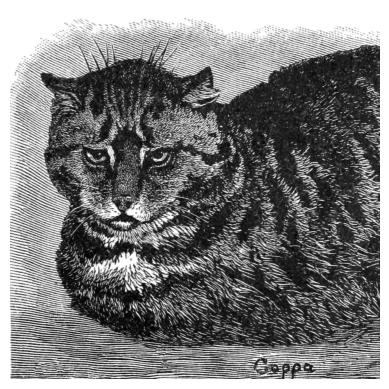

In [2]:
image = np.array(Image.open("cat1368.pgm"))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

Let us apply the cat map once.

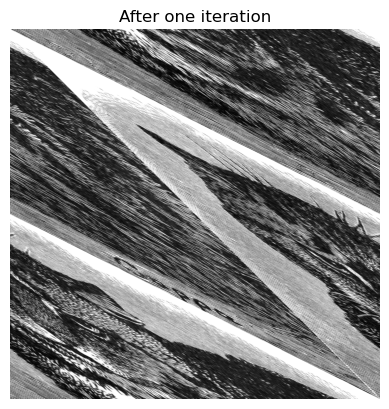

In [3]:
plt.imshow(CatMap(image, 1), cmap="gray")
plt.title(f"After one iteration")
plt.axis("off")
plt.show()

Arnold's cat map has interesting properties. Let $C^n(x, y)$ be the
$n$-th iterate of $C$, i.e.:

\begin{equation*}
C^n(x, y) = \begin{cases}
(x, y) & \mbox{if $n=0$}\\
C(C^{n-1}(x,y)) & \mbox{if $n>0$}
\end{cases}
\end{equation*}

Therefore, $C^2(x,y) = C(C(x,y))$, $C^3(x,y) = C(C(C(x,y)))$, and so
on.

If we apply $C$ once, we get a severely distorted version of the
input. If we apply $C$ again on the result, we get an even more
distorted image. As we keep applying $C$, the original image is no
longer discernible. However, after a certain number of iterations,
that depends on the image size $N$ and has been proved to never exceed
$3N$, we get back the original image!

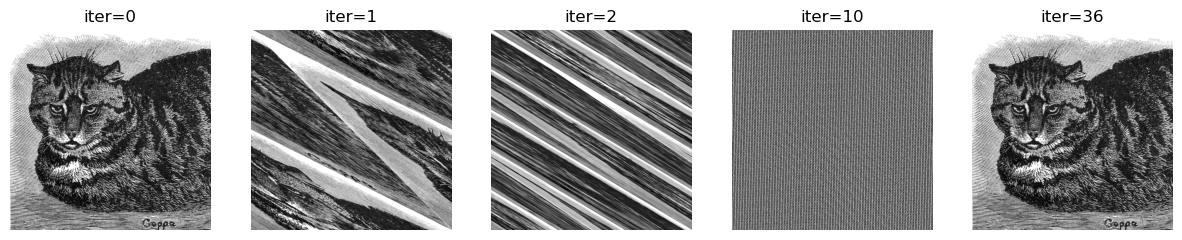

In [4]:
iters = [0, 1, 2, 10, 36]
nplots = len(iters)

plt.subplots(1, nplots, figsize=(15,3))
for i,nit in enumerate(iters, start=1):
    plt.subplot(1, nplots, i)
    plt.imshow(CatMap(image, nit), cmap="gray");
    plt.title(f"iter={nit:d}")
    plt.axis("off")
plt.show()

The transformation is invertible; the inverse $C^{-1}(x', y')$ is defined as:

\begin{align*}
x &= (x' - y') \bmod N\\
y &= (-x' + 2y') \bmod N
\end{align*}

In [5]:
def CatMapInverse(bmap, n):
    """
    Return the bitmap obtained by applying
    n times the inverse of the cat map to bmap
    """
    [rows, cols] = bmap.shape
    assert rows == cols, "Image must be square"
    x, y = np.meshgrid(range(cols), range(rows))
    xmap = (x - y) % cols
    ymap = (-x + 2*y) % rows
    result = np.zeros(bmap.shape)
    for _ in range(n):
        result[ymap,xmap] = bmap
        bmap = result.copy()
    return bmap

Let us check whether this is correct.

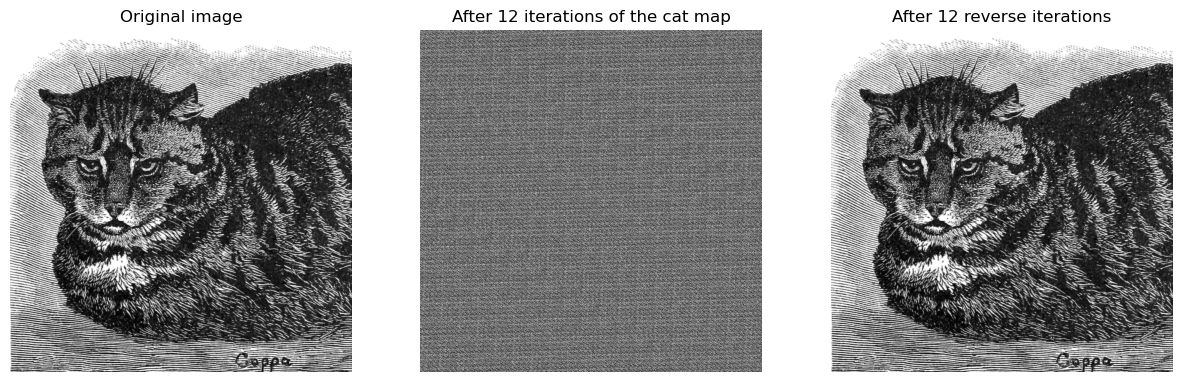

In [6]:
image = np.array(Image.open("cat1368.pgm"))

# original image
plt.subplots(1,3, figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(image, cmap="gray");
plt.title("Original image")
plt.axis("off")

# cat map forward 12 steps
plt.subplot(1,3,2)
image = CatMap(image, 12)
plt.imshow(image, cmap="gray");
plt.title("After 12 iterations of the cat map")
plt.axis("off")

# cat map inverse 12 steps
plt.subplot(1,3,3)
image = CatMapInverse(image, 12)
plt.imshow(image, cmap="gray")
plt.title("After 12 reverse iterations")
plt.axis("off")

plt.show()

The _minimum recurrence time_ is the minimum number of iterations $k
\geq 1$ that produce the original image, i.e., the minimum value of $k \geq 1$
such that $C^k(x, y) = (x, y)$ for all $(x, y)$.

> **Question** Can you prove that every image gets eventually mapped back to itself? (Hint: prova that every point must get back to the initial position; to do this, you may show that orbits that take a point towards a cycle that does not include the initial position can never happen).

To compute the minimum recurrence time, let us first define a function `period(x, y, N)` that computes the recurrence time of point `x, y`, i.e., the minimum number of iterations that are required for the point `x,y` to get mapped back into the original position.

In [7]:
def period(x, y, N):
    """ 
    Return the period of the point of coordinates (x,y) 
    under iterations of the cat map on an image of size NxN.
    The period is defined as the minimum number of iterations
    k >= 1 such that point (x,y) is mapped back to its
    initial position
    """
    x0, y0 = x, y
    x, y = ((2*x+y) % N), ((x + y) % N)
    k = 1
    while (x != x0) or (y != y0):
        x, y = ((2*x+y) % N), ((x + y) % N)
        k = k + 1
    return k

The minimum recurrence time of an image of size $N \times N$ is the Least Common Multiple (LCM) of the periods of all points it contains.

In [8]:
def recurrence_time(N):
    """
    Return the minimum recurrence time for an image of size
    NxN under the cat map.
    """
    #result = 1
    #for i in range(N):
    #    for j in range(N):
    #        result = np.lcm(result, period(i,j,N))
    result = np.lcm.reduce([period(i,j,N) for i in range(N) for j in range (N)])
    return result

For example, the minimum recurrence time for
[cat1368.pgm](cat1368.pgm) of size $1368 \times 1368$ is $36$.

In [9]:
recurrence_time(1368)

36

The minimum recurrence time depends on the image size $N$ only. No closed formula is known to compute the minimum recurrence time given $N$, although there are results and bounds that apply to specific cases. If we plot the recurrence times as a function of $N$, we observe that the values are not completely random but tend to align along straight lines, suggesting that there is indeed some pattern that remains elusive.

Elapsed time: 0.2s


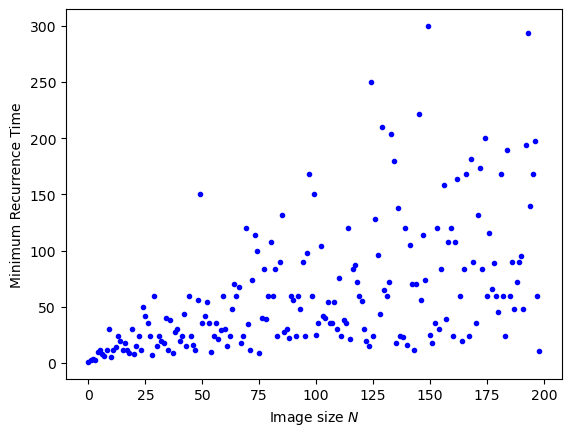

In [10]:
start = time.time()
r = [recurrence_time(x) for x in range(1,200)]
stop = time.time()
print(f"Elapsed time: {.2}s".format(stop - start))
plt.plot(r, '.b')
plt.xlabel("Image size $N$")
plt.ylabel("Minimum Recurrence Time")
plt.show()